# EDA — NVDA MBP-1

Exploratory analysis of the order-update stream.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_mbp1

df = load_mbp1("data/nvda_mbp1_2026-06-01.parquet")
df.shape

(3336062, 19)

## Order updates per minute

Each row is one order-book update (add / cancel / trade). Resample the
event timestamps to 1-minute bins and count.

In [4]:
# Count rows (order updates) in each 1-minute bin.
updates_per_min = (
    df.set_index("ts_event")
      .resample("1min")
      .size()
)

print(f"average updates per minute: {updates_per_min.mean()}")
updates_per_min

average updates per minute: 8554.005128205128


ts_event
2026-06-01 09:30:00-04:00    30956
2026-06-01 09:31:00-04:00    57054
2026-06-01 09:32:00-04:00    30600
2026-06-01 09:33:00-04:00    35719
2026-06-01 09:34:00-04:00    26124
                             ...  
2026-06-01 15:55:00-04:00    12660
2026-06-01 15:56:00-04:00    12113
2026-06-01 15:57:00-04:00    15348
2026-06-01 15:58:00-04:00    14014
2026-06-01 15:59:00-04:00    27829
Freq: min, Length: 390, dtype: int64

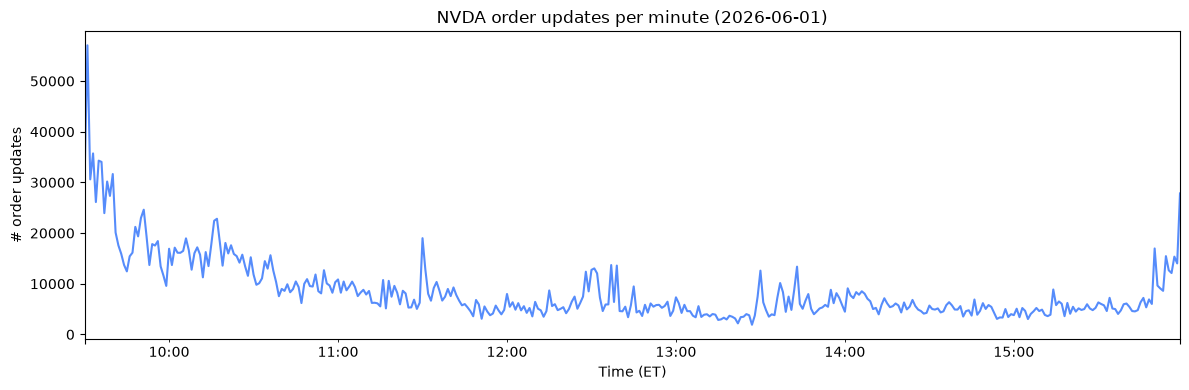

In [3]:
# Plot it.
ax = updates_per_min.plot(figsize=(12, 4), title="NVDA order updates per minute (2026-06-01)")
ax.set_xlabel("Time (ET)")
ax.set_ylabel("# order updates")
plt.tight_layout()
plt.show()